In [21]:
import numpy as np
import uproot


def get_centroid_array(
    file_numbers, obj_name="ADC_HIGH_7", base_path="summer{:03d}.root"
):
    """slitB0-[000].root から指定した番号順に重心の数列（NumPy配列）を返します。

    Parameters:
    -----------
    file_numbers : list or iterable
        取得したいファイル番号のリスト（例: range(0, 10)）
    obj_name : str, default "ADC_HIGH_7"
        読み出すヒストグラム名
    base_path : str
        ファイル名のパターン（{:03d} は3桁ゼロパディング）

    Returns:
    --------
    np.ndarray
        重心（Mean）が順番に格納された1次元NumPy配列
    """
    centroids = []

    for n in file_numbers:
        file_name = base_path.format(n)

        try:
            with uproot.open(file_name) as f:
                hist = f[obj_name]
                values = hist.values()
                x_edges = hist.axes[0].edges()

            x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
            total_counts = np.sum(values)

            if total_counts > 0:
                mean = np.sum(x_centers * values) / total_counts
            else:
                mean = np.nan

            centroids.append(mean)

        except Exception:
            # ファイルが存在しない・読み込めない場合は nan を追加
            centroids.append(np.nan)

    return np.array(centroids)

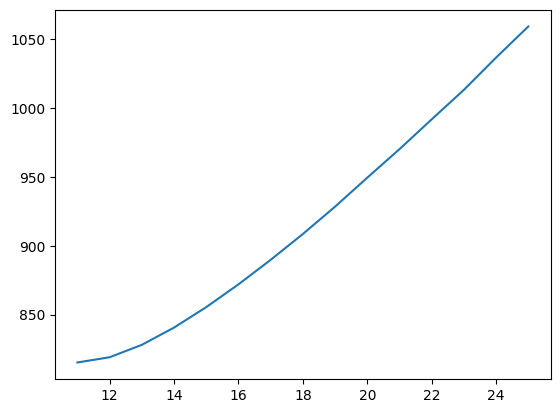

In [26]:
import matplotlib.pyplot as plt
file_numbers = range(11, 26)
import numpy as np

x = np.arange(11, 26, 1)


sama=get_centroid_array(file_numbers)
plt.plot(x,sama)
plt.show()